# Feature Visualizations

Explores relationships between **automatic features** (`features.csv`) and **manual annotation dimensions** across all three tasks (event relation, agency, setting).

Annotations are from annotator `tejo9855`, who has labeled all three tasks.  
Run `automatic_features/extract_features.py` first to generate `features.csv`.

In [1]:
import json
import csv
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import spearmanr, pearsonr

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120

## Load Data

In [2]:
BASE = '../..'   # from annotation_analysis/ up to potato/teagan_tasks/..
# adjust if running from a different working directory
import os
BASE = os.path.join(os.path.dirname(os.path.abspath('.')), 'teagan_tasks') \
       if os.path.basename(os.getcwd()) != 'annotation_analysis' else '..'

FEATURES_CSV  = f'{BASE}/automatic_features/features.csv'
DATA_CSV      = f'{BASE}/event_relation_annotation_task/data/dolma_combined_final_sample_700_with_llm_summary_safeid_with_spans.csv'
ER_STATE      = f'{BASE}/event_relation_annotation_task/annotation_output/results/tejo9855/user_state.json'
AG_STATE      = f'{BASE}/agency_annotation_task/agency_annotations/annotation_output/results/tejo9855/user_state.json'
ST_STATE      = f'{BASE}/setting_annotation_task/annotation_output/results/tejo9855/user_state.json'
ANNOTATOR     = 'tejo9855'

In [3]:
# ── Automatic features ────────────────────────────────────────────────────────
feat_df = pd.read_csv(FEATURES_CSV)
print(f'Automatic features: {len(feat_df)} rows x {len(feat_df.columns)} cols')

# ── Source / topic metadata ────────────────────────────────────────────────────
csv.field_size_limit(10**7)
with open(DATA_CSV) as f:
    meta_rows = list(csv.DictReader(f))
meta_df = pd.DataFrame([{
    'safe_instance_id': r['safe_instance_id'],
    'source':           r['source'],
    'topic_classification': r['topic_classification'],
    'narrative_label':  r['narrative_label'],
} for r in meta_rows])

feat_df = feat_df.merge(meta_df, on='safe_instance_id', how='left')
print(f'After metadata merge: {len(feat_df)} rows')

# ── Event relation annotations (tejo9855) ──────────────────────────────────────
def parse_event_relation(val):
    inner = val[0][1]
    if not inner: return None
    parsed = json.loads(inner)
    return parsed[0] if parsed else None

with open(ER_STATE) as f:
    er_state = json.load(f)

er_rows = []
for inst_id, val in er_state['instance_id_to_label_to_value'].items():
    ann = parse_event_relation(val)
    if ann is None: continue
    row = {'safe_instance_id': inst_id}
    row['er_span1_event']   = int(bool(ann.get('span1_is_event')))
    row['er_span2_event']   = int(bool(ann.get('span2_is_event')))
    if ann.get('span1_is_event') and ann.get('span2_is_event'):
        row['er_sequencing'] = ann.get('sequencing_rating')
        row['er_causality']  = ann.get('causality_rating')
    else:
        row['er_sequencing'] = None
        row['er_causality']  = None
    er_rows.append(row)
er_df = pd.DataFrame(er_rows)
print(f'Event relation: {len(er_df)} instances, '
      f'{er_df["er_sequencing"].notna().sum()} with sequencing/causality')

# ── Agency annotations ─────────────────────────────────────────────────────────
def parse_likert(val):
    result = {}
    for entry in val:
        result[entry[0]['schema']] = int(entry[0]['name'])
    return result

with open(AG_STATE) as f:
    ag_state = json.load(f)

ag_rows = []
for inst_id, val in ag_state['instance_id_to_label_to_value'].items():
    ann = parse_likert(val)
    row = {'safe_instance_id': inst_id}
    for dim in ['agency_focalization','agency_emotion','agency_cognition',
                'agency_motivation','agency_change_of_state','agency_conflict']:
        row[dim] = ann.get(dim)
    ag_rows.append(row)
ag_df = pd.DataFrame(ag_rows)
print(f'Agency: {len(ag_df)} instances')

# ── Setting annotations ────────────────────────────────────────────────────────
with open(ST_STATE) as f:
    st_state = json.load(f)

st_rows = []
for inst_id, val in st_state['instance_id_to_label_to_value'].items():
    ann = parse_likert(val)
    row = {'safe_instance_id': inst_id}
    for dim in ['setting_concreteness','setting_temporal_grounding',
                'setting_spatial_grounding','setting_sensory']:
        row[dim] = ann.get(dim)
    st_rows.append(row)
st_df = pd.DataFrame(st_rows)
print(f'Setting: {len(st_df)} instances')

# ── Merged dataframes ──────────────────────────────────────────────────────────
# full: automatic features + metadata (679 rows)
# ann:  automatic + all manual annotations (21 shared instances)
# er_full: automatic + event relation (51 instances)
full_df   = feat_df.copy()
ann_df    = feat_df.merge(ag_df, on='safe_instance_id') \
                   .merge(st_df, on='safe_instance_id') \
                   .merge(er_df, on='safe_instance_id')
er_full_df = feat_df.merge(er_df, on='safe_instance_id')

print(f'\nJoint annotation dataframe: {len(ann_df)} instances')
print(f'Event relation + features:  {len(er_full_df)} instances')

Automatic features: 679 rows x 14 cols
After metadata merge: 679 rows
Event relation: 51 instances, 29 with sequencing/causality
Agency: 21 instances
Setting: 21 instances

Joint annotation dataframe: 21 instances
Event relation + features:  51 instances


## 1. Automatic vs Manual Concordance

Do the automatic proxies track what annotators actually judged?
- **Brysbaert concreteness** vs annotated `setting_concreteness`
- **Temporal mention rate** vs annotated `setting_temporal_grounding`

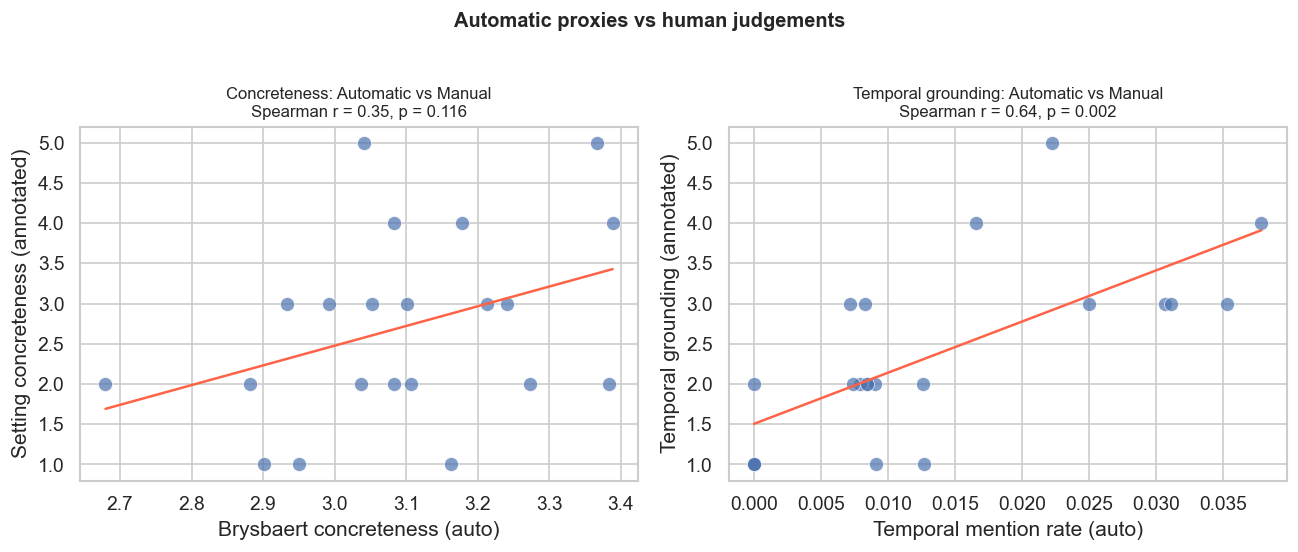

In [4]:
def annotated_scatter(ax, df, x_col, y_col, xlabel, ylabel, title):
    sub = df[[x_col, y_col]].dropna()
    if len(sub) < 3:
        ax.text(0.5, 0.5, 'insufficient data', ha='center', va='center', transform=ax.transAxes)
        return
    r_s, p_s = spearmanr(sub[x_col], sub[y_col])
    ax.scatter(sub[x_col], sub[y_col], alpha=0.7, edgecolors='white', linewidths=0.5, s=70)
    # regression line
    m, b = np.polyfit(sub[x_col], sub[y_col], 1)
    xs = np.linspace(sub[x_col].min(), sub[x_col].max(), 100)
    ax.plot(xs, m*xs + b, color='tomato', lw=1.5, zorder=3)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(f'{title}\nSpearman r = {r_s:.2f}, p = {p_s:.3f}', fontsize=10)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

annotated_scatter(axes[0], ann_df,
    'concreteness_mean', 'setting_concreteness',
    'Brysbaert concreteness (auto)', 'Setting concreteness (annotated)',
    'Concreteness: Automatic vs Manual')

annotated_scatter(axes[1], ann_df,
    'temporal_mention_rate', 'setting_temporal_grounding',
    'Temporal mention rate (auto)', 'Temporal grounding (annotated)',
    'Temporal grounding: Automatic vs Manual')

plt.suptitle('Automatic proxies vs human judgements', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 2. Theory-Driven Correlations

### 2a. Sentiment × Agency Conflict & Emotion

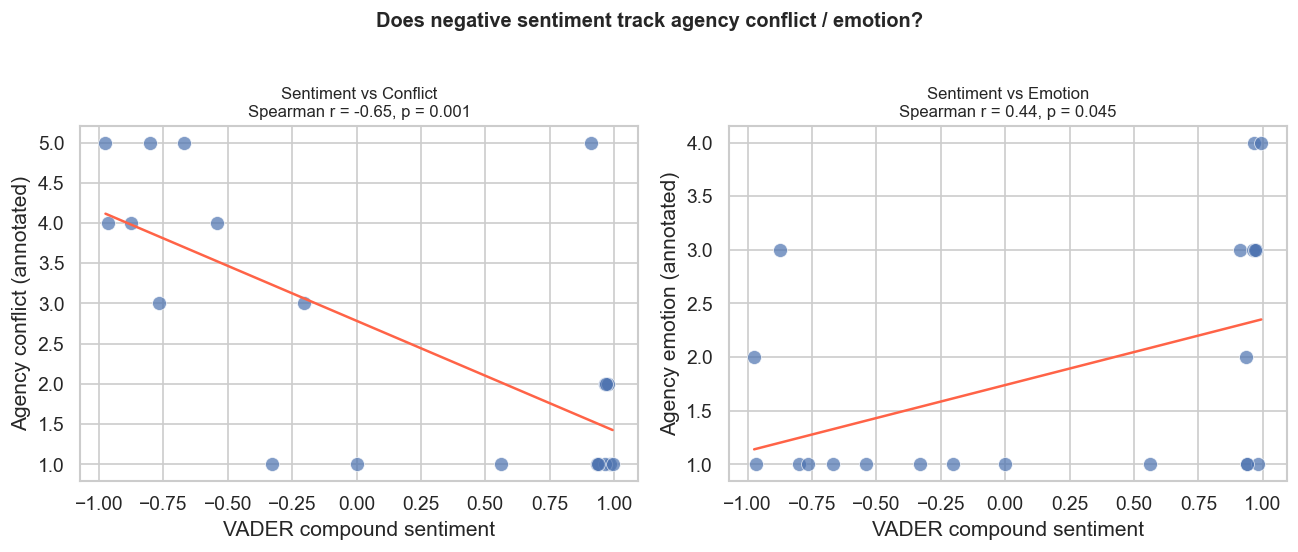

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

annotated_scatter(axes[0], ann_df,
    'sentiment_compound', 'agency_conflict',
    'VADER compound sentiment', 'Agency conflict (annotated)',
    'Sentiment vs Conflict')

annotated_scatter(axes[1], ann_df,
    'sentiment_compound', 'agency_emotion',
    'VADER compound sentiment', 'Agency emotion (annotated)',
    'Sentiment vs Emotion')

plt.suptitle('Does negative sentiment track agency conflict / emotion?',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 2b. Past Tense Verb Rate × Event Relation Sequencing

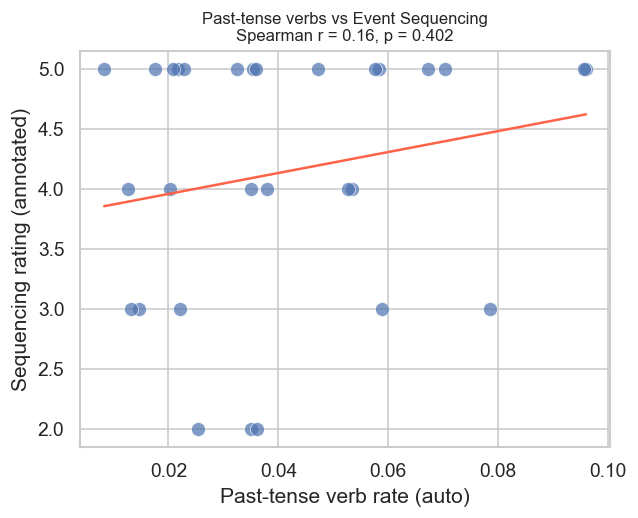

N = 29 instances with sequencing annotations


In [6]:
seq_df = er_full_df[['past_tense_verb_rate', 'er_sequencing']].dropna()

fig, ax = plt.subplots(figsize=(5.5, 4.5))
annotated_scatter(ax, seq_df,
    'past_tense_verb_rate', 'er_sequencing',
    'Past-tense verb rate (auto)', 'Sequencing rating (annotated)',
    'Past-tense verbs vs Event Sequencing')
plt.tight_layout()
plt.show()
print(f'N = {len(seq_df)} instances with sequencing annotations')

### 2c. POV × Agency Dimensions (grouped boxplots)

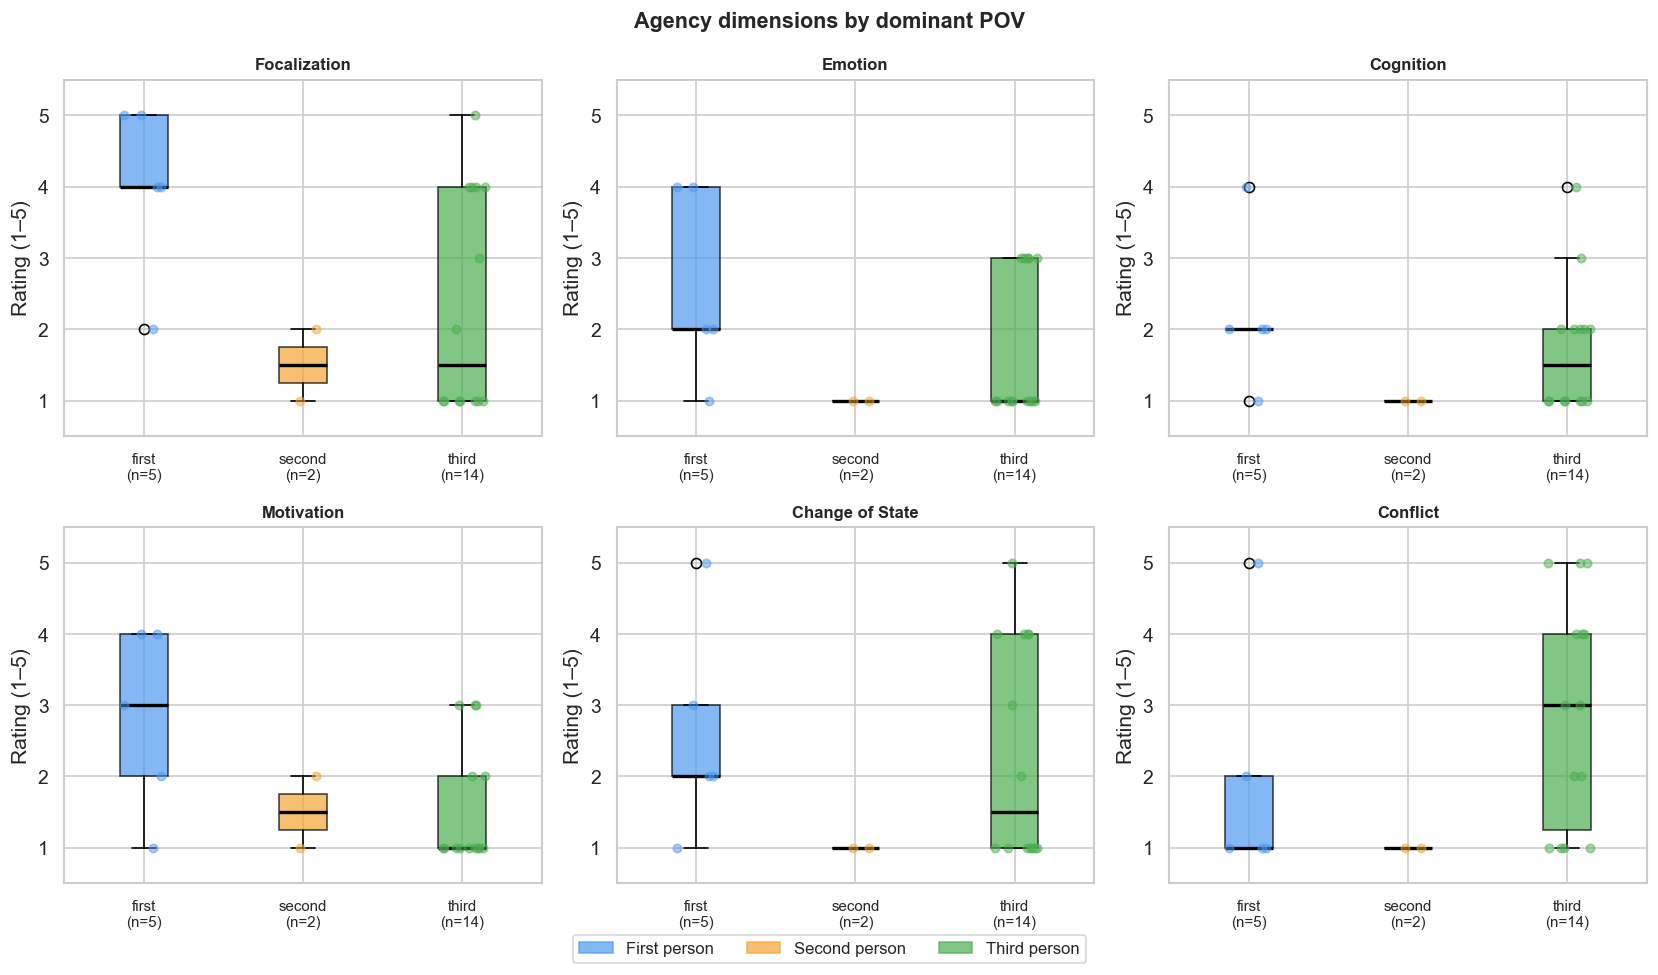

In [7]:
agency_dims = ['agency_focalization','agency_emotion','agency_cognition',
               'agency_motivation','agency_change_of_state','agency_conflict']
dim_labels  = ['Focalization','Emotion','Cognition','Motivation','Change of State','Conflict']

pov_df = ann_df[ann_df['pov_dominant'] != 'none'].copy()
pov_order = ['first', 'second', 'third']
pov_colors = {'first': '#4e9af1', 'second': '#f4a432', 'third': '#4caf50'}

fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey=False)
axes = axes.flatten()

for i, (dim, label) in enumerate(zip(agency_dims, dim_labels)):
    ax = axes[i]
    sub = pov_df[['pov_dominant', dim]].dropna()
    present_pov = [p for p in pov_order if p in sub['pov_dominant'].values]
    data_by_pov = [sub[sub['pov_dominant'] == p][dim].values for p in present_pov]
    bp = ax.boxplot(data_by_pov, labels=present_pov, patch_artist=True,
                    medianprops=dict(color='black', lw=2))
    for patch, pov in zip(bp['boxes'], present_pov):
        patch.set_facecolor(pov_colors[pov])
        patch.set_alpha(0.7)
    # overlay jittered points
    for j, (pov, d) in enumerate(zip(present_pov, data_by_pov)):
        jitter = np.random.default_rng(42).uniform(-0.15, 0.15, len(d))
        ax.scatter(np.full(len(d), j+1) + jitter, d,
                   color=pov_colors[pov], alpha=0.5, s=25, zorder=3)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_ylabel('Rating (1–5)')
    ax.set_ylim(0.5, 5.5)
    counts = {p: (sub['pov_dominant']==p).sum() for p in present_pov}
    ax.set_xticklabels([f'{p}\n(n={counts[p]})' for p in present_pov], fontsize=9)

patches = [mpatches.Patch(color=pov_colors[p], alpha=0.7, label=f'{p.capitalize()} person')
           for p in pov_order]
fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=10, frameon=True,
           bbox_to_anchor=(0.5, -0.02))
fig.suptitle('Agency dimensions by dominant POV', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Automatic × Manual Correlation Heatmap

Spearman correlations between all automatic features and all manual annotation dimensions.

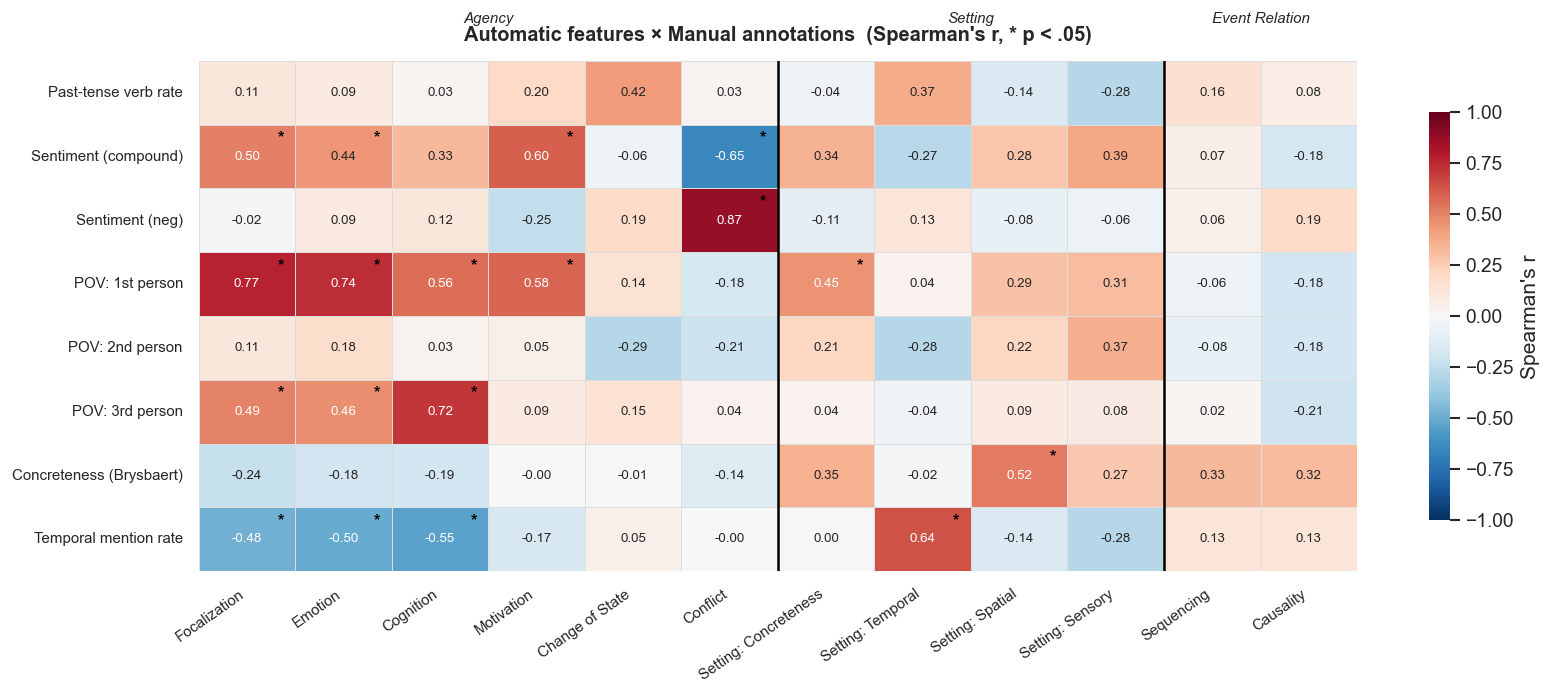

In [8]:
auto_cols = ['past_tense_verb_rate', 'sentiment_compound', 'sentiment_neg',
             'pov_first_rate', 'pov_second_rate', 'pov_third_rate',
             'concreteness_mean', 'temporal_mention_rate']
auto_labels = ['Past-tense verb rate', 'Sentiment (compound)', 'Sentiment (neg)',
               'POV: 1st person', 'POV: 2nd person', 'POV: 3rd person',
               'Concreteness (Brysbaert)', 'Temporal mention rate']

manual_cols = (agency_dims +
               ['setting_concreteness','setting_temporal_grounding',
                'setting_spatial_grounding','setting_sensory'] +
               ['er_sequencing','er_causality'])
manual_labels = (['Focalization','Emotion','Cognition','Motivation','Change of State','Conflict'] +
                 ['Setting: Concreteness','Setting: Temporal','Setting: Spatial','Setting: Sensory'] +
                 ['Sequencing','Causality'])

corr_matrix = np.full((len(auto_cols), len(manual_cols)), np.nan)
pval_matrix = np.full((len(auto_cols), len(manual_cols)), np.nan)

for i, ac in enumerate(auto_cols):
    for j, mc in enumerate(manual_cols):
        sub = ann_df[[ac, mc]].dropna() if mc not in ['er_sequencing','er_causality'] \
              else er_full_df[[ac, mc]].dropna()
        if len(sub) >= 4:
            r, p = spearmanr(sub[ac], sub[mc])
            corr_matrix[i, j] = r
            pval_matrix[i, j] = p

corr_df = pd.DataFrame(corr_matrix, index=auto_labels, columns=manual_labels)

fig, ax = plt.subplots(figsize=(14, 6))
mask = np.isnan(corr_matrix)
sns.heatmap(corr_df, ax=ax, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 8},
            linewidths=0.4, linecolor='#ddd', mask=mask,
            cbar_kws={'label': "Spearman's r", 'shrink': 0.8})

# mark significant cells (p < .05) with *
for i in range(len(auto_cols)):
    for j in range(len(manual_cols)):
        if not np.isnan(pval_matrix[i,j]) and pval_matrix[i,j] < 0.05:
            ax.text(j + 0.85, i + 0.2, '*', ha='center', va='center',
                    fontsize=10, color='black', fontweight='bold')

ax.set_title("Automatic features × Manual annotations  (Spearman's r, * p < .05)",
             fontsize=12, fontweight='bold', pad=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

# vertical separator between agency / setting / event relation column groups
ax.axvline(6,  color='black', lw=1.5)
ax.axvline(10, color='black', lw=1.5)
ax.text(3,   -0.6, 'Agency',         ha='center', fontsize=9, style='italic')
ax.text(8,   -0.6, 'Setting',        ha='center', fontsize=9, style='italic')
ax.text(11,  -0.6, 'Event Relation', ha='center', fontsize=9, style='italic')

plt.tight_layout()
plt.show()

## 4. POV Groups × All Annotation Dimensions

Violin plots for every annotation dimension split by dominant POV.

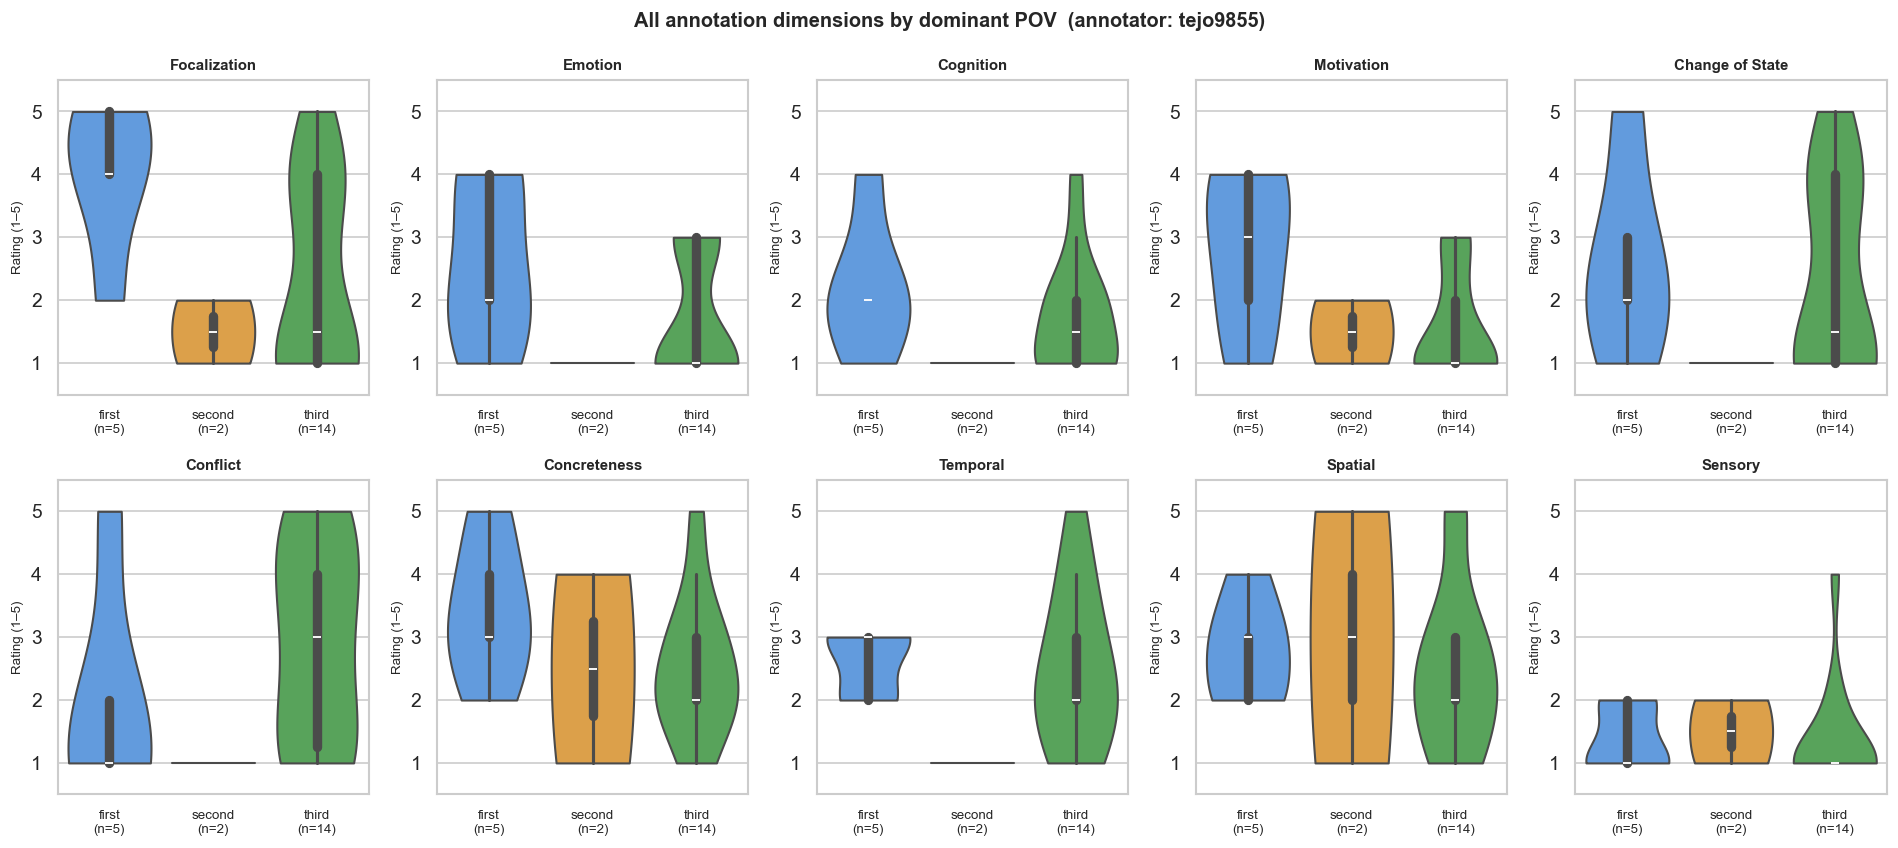

In [9]:
all_dims   = (agency_dims +
              ['setting_concreteness','setting_temporal_grounding',
               'setting_spatial_grounding','setting_sensory'])
all_labels = (['Focalization','Emotion','Cognition','Motivation','Change of State','Conflict'] +
              ['Concreteness','Temporal','Spatial','Sensory'])

pov_df = ann_df[ann_df['pov_dominant'] != 'none'].copy()
n_dims = len(all_dims)
ncols = 5
nrows = -(-n_dims // ncols)   # ceiling division

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*3.2, nrows*3.6), sharey=False)
axes = axes.flatten()

for i, (dim, label) in enumerate(zip(all_dims, all_labels)):
    ax = axes[i]
    sub = pov_df[['pov_dominant', dim]].dropna()
    present = [p for p in pov_order if p in sub['pov_dominant'].values]
    if len(sub) >= 3 and len(present) >= 2:
        sns.violinplot(data=sub, x='pov_dominant', y=dim, order=present,
                       palette=pov_colors, inner='box', ax=ax,
                       cut=0, density_norm='width')
        ax.set_xticklabels([f'{p}\n(n={(sub["pov_dominant"]==p).sum()})' for p in present],
                           fontsize=8)
    else:
        ax.text(0.5, 0.5, 'n too small', ha='center', va='center', transform=ax.transAxes,
                color='#999', fontsize=9)
    ax.set_title(label, fontsize=9, fontweight='bold')
    ax.set_ylim(0.5, 5.5)
    ax.set_xlabel('')
    ax.set_ylabel('Rating (1–5)', fontsize=8)

# hide unused axes
for ax in axes[n_dims:]:
    ax.set_visible(False)

fig.suptitle('All annotation dimensions by dominant POV  (annotator: tejo9855)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Automatic Feature Distributions by Source & Topic

Do texts from different sources or topics differ systematically in automatic features?

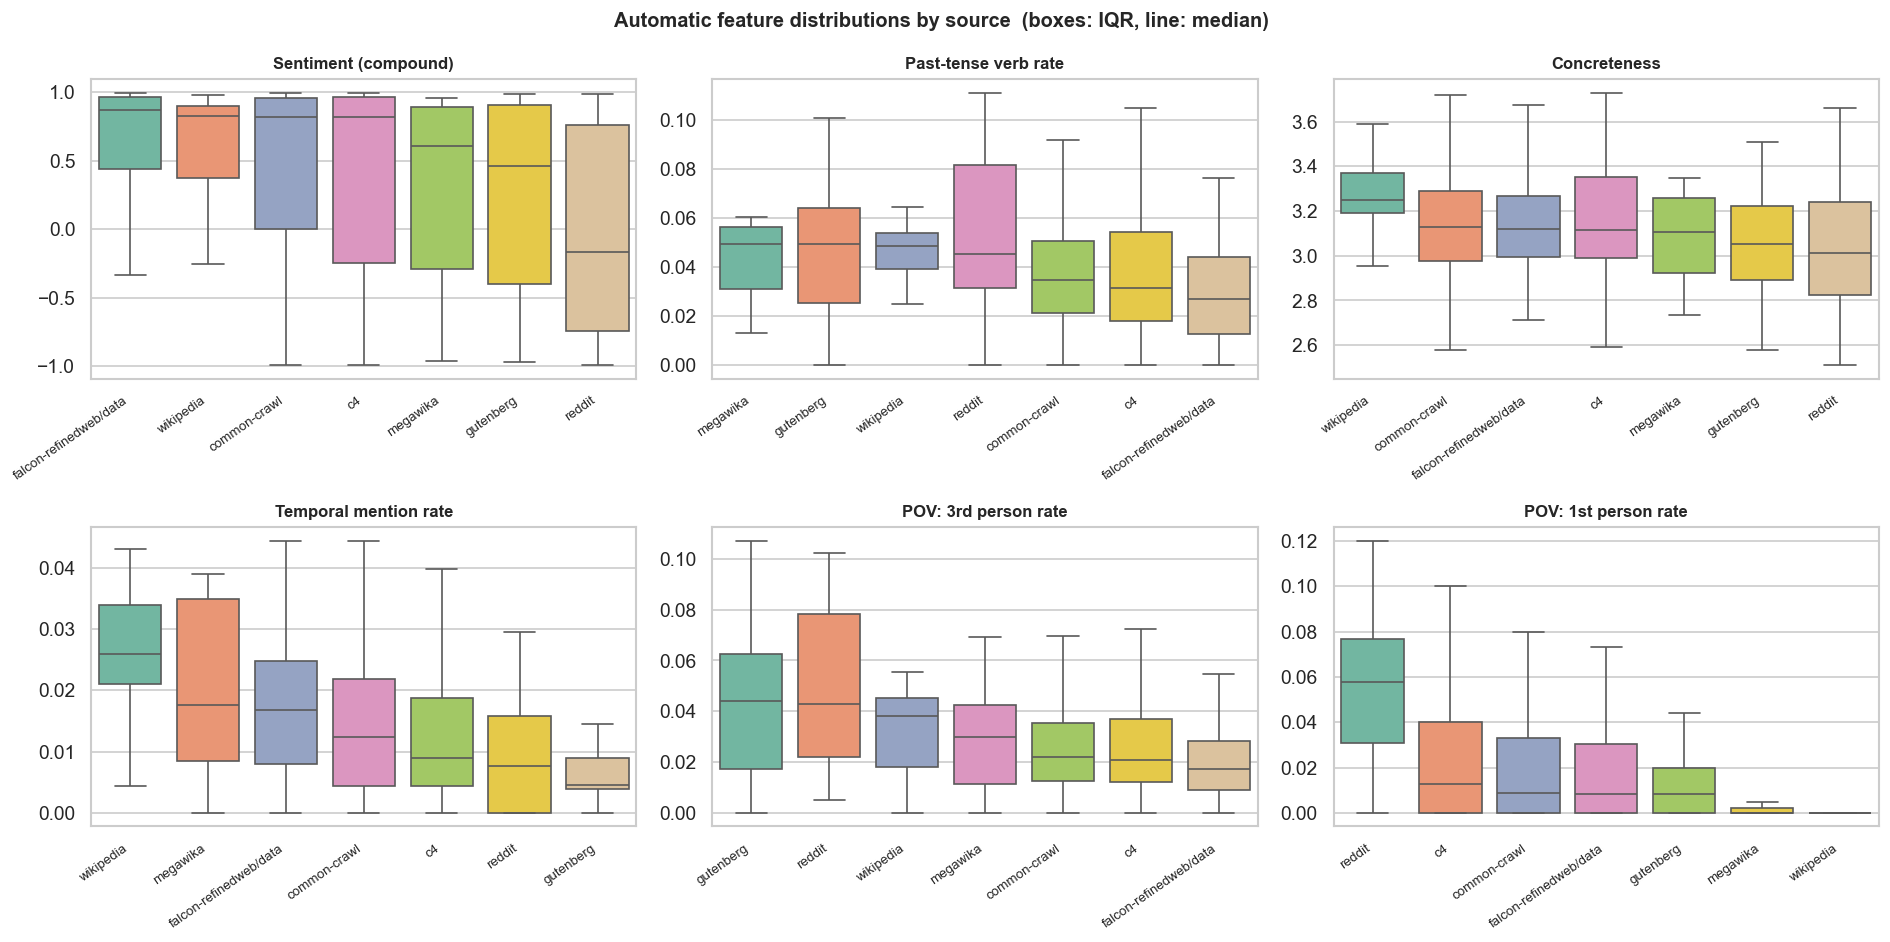

In [10]:
# ── By source ─────────────────────────────────────────────────────────────────
plot_features = ['sentiment_compound', 'past_tense_verb_rate',
                 'concreteness_mean', 'temporal_mention_rate',
                 'pov_third_rate', 'pov_first_rate']
feat_labels   = ['Sentiment (compound)', 'Past-tense verb rate',
                 'Concreteness', 'Temporal mention rate',
                 'POV: 3rd person rate', 'POV: 1st person rate']

src_counts = full_df['source'].value_counts()
top_sources = src_counts[src_counts >= 10].index.tolist()
src_df = full_df[full_df['source'].isin(top_sources)].copy()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, (feat, flabel) in enumerate(zip(plot_features, feat_labels)):
    ax = axes[i]
    order = (src_df.groupby('source')[feat].median()
                   .sort_values(ascending=False).index.tolist())
    sns.boxplot(data=src_df, x='source', y=feat, order=order,
                palette='Set2', ax=ax, showfliers=False)
    ax.set_title(flabel, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=8)
    ax.set_ylabel('')

fig.suptitle('Automatic feature distributions by source  (boxes: IQR, line: median)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── By topic ──────────────────────────────────────────────────────────────────
topic_counts = full_df['topic_classification'].value_counts()
top_topics   = topic_counts[topic_counts >= 8].index.tolist()
top_df       = full_df[full_df['topic_classification'].isin(top_topics)].copy()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, (feat, flabel) in enumerate(zip(plot_features, feat_labels)):
    ax = axes[i]
    order = (top_df.groupby('topic_classification')[feat].median()
                   .sort_values(ascending=False).index.tolist())
    sns.boxplot(data=top_df, x='topic_classification', y=feat, order=order,
                palette='tab10', ax=ax, showfliers=False)
    ax.set_title(flabel, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=7)
    ax.set_ylabel('')

fig.suptitle('Automatic feature distributions by topic  (boxes: IQR, line: median)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()